# Event Attention-Curve Clustering with Sliding SAX

```text
Google Trends chunk files
        ↓
overlap-rolling stitched daily series
        ↓
quality diagnostics
        ↓
light denoising
        ↓
detrending
        ↓
robust per-series normalization
        ↓
sliding SAX parameter tuning
        ├── window_size
        ├── step_size
        ├── PAA word length w / n_segments
        └── alphabet_size a
        ↓
SAX feature matrix
        ↓
KMeans / Ward clustering
        ↓
cluster interpretation tables and plots
```

The notebook **does not re-query Google Trends**. It treats the existing overlap-rolling stitched files under
`DATA_DIR/<query>/stitched/` as the canonical daily input.

## External references used for this revision

1. `candicedjorno/replication-restoring-google-trends` motivates the preprocessing order: cluster or group related terms, smooth/denoise noisy Google Trends curves, then detrend before modeling. In this notebook, that logic is adapted to an unsupervised SAX clustering setting rather than forecasting.
   - Repository: https://github.com/candicedjorno/replication-restoring-google-trends
   - Relevant ideas/files: `scripts/01_clustering/hierarchical_clustering.ipynb`, `scripts/02_denoising/gt_denoising.R`, `scripts/03_detrending/detrending.py`

2. `trendecon/trendecon` motivates careful construction of consistent long daily Google Trends series. Since the current project has already downloaded chunk-level daily data and stitched it with overlap scaling, this notebook does **not** implement trendEcon's multi-frequency reconstruction. It instead adds diagnostics and post-stitch preprocessing.
   - Repository: https://github.com/trendecon/trendecon
   - Documentation: https://trendecon.github.io/trendecon/reference/ts_gtrends_mwd.html
   - Relevant idea: robust long daily Google Trends series from daily/weekly/monthly harmonization; here used as conceptual guidance, not as executable dependency.

## Main revision choices

- Removed the consensus-matrix / graph-clustering tuning from the core workflow.
- Kept only the three SAX tuning families requested:
  - `window_size`
  - `step_size`
  - `PAA word length w`, implemented as `n_segments`
  - `alphabet_size a`
- Separated **representation tuning** from **cluster-count selection**.
- Added robust preprocessing functions: small-gap interpolation, light denoising, detrending, and robust z-scoring.
- Added output notes so every selected parameter setting is saved for reporting.


## Efficiency revision added

This version also improves computation efficiency in the SAX tuning stage by:

- caching clean NumPy arrays once instead of repeatedly converting each pandas Series;
- caching sliding windows by `(window_size, step)` so the same windows are reused across PAA and alphabet settings;
- computing PAA segment means with cumulative sums instead of Python loops over every window;
- vectorizing SAX discretization with `np.searchsorted`;
- using sampled silhouette scores during grid search to avoid expensive pairwise-distance calculations on large term sets;
- using a smaller `n_init` for tuning and reserving heavier `KMeans` only for the final selected model.


In [ ]:
from __future__ import annotations

import json
import warnings
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
from numpy.lib.stride_tricks import sliding_window_view

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.signal import savgol_filter
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# -----------------------------------------------------------------------------
# CONFIG -- edit for your local machine
# -----------------------------------------------------------------------------

DATA_DIR = Path(r"C:\Python\CSUREMM\data_events")
OUTPUT_DIR = Path(r"C:\Python\CSUREMM\output\sax_tests_july_06")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Current folder structure:
# DATA_DIR/
#     query_metadata.csv
#     weather/
#         chunks/
#         diagnostics/
#         stitched/
#             gt_fixed_weather_2022-01-01_2026-05-31.csv
STITCHED_SUBDIR = "stitched"
STITCHED_GLOB = "gt_fixed_*.csv"

# Preprocessing controls.
MAX_INTERPOLATE_GAP = 7       # fill missing gaps up to one week
DENOISE_WINDOW = 15           # odd integer; light smoothing only
DENOISE_POLYORDER = 2
DETREND_WINDOW = 91           # 13-week rolling median trend

# SAX tuning grid. PAA word length w is named n_segments in the code.
WINDOW_GRID = [60, 90, 180] # removed 365 days because it was too coarse for the 2022-2026 data
STEP_FRACTIONS = [0.25]       # step = round(window_size * fraction)
PAA_WORD_LENGTH_GRID = [8, 12, 16, 24, 32, 52]
ALPHABET_GRID = [3, 4, 5, 6]

# Clustering grid. This is evaluated after a SAX representation is built.
K_GRID = range(2, 8)
RANDOM_STATE = 42

# --- Anti-degeneracy / balance controls -------------------------------------
# A k=2 split that isolates a handful of outlier terms from everything else
# is statistically "clean" (high silhouette) but not interpretable. These
# controls stop the autoselection stage from rewarding that kind of split.
MIN_CLUSTER_FRACTION = 0.08   # smallest allowed cluster, as a fraction of n_terms
BALANCE_METRIC = "norm_entropy"  # "norm_entropy" or "min_frac"

# --- Multi-resolution (layered) clustering -----------------------------------
LAYER_KS = (3, 6, 10)   # coarse -> meso -> fine cuts of the same dendrogram

# --- Consensus clustering -----------------------------------------------------
CONSENSUS_K_RANGE = range(2, 11)
CONSENSUS_N_RESAMPLES = 200
CONSENSUS_SUBSAMPLE_FRAC = 0.8

# Optional spike features summarize the full preprocessed curve in addition to symbolic shape.
INCLUDE_SPIKE_FEATURES = True

# Efficiency controls for tuning.
# Silhouette is O(n_terms^2); sampling makes grid search much faster on large panels.
TUNING_KMEANS_N_INIT = 10
FINAL_KMEANS_N_INIT = 50
SILHOUETTE_SAMPLE_SIZE = 500
USE_WINDOW_CACHE = True


## 1. Load stitched daily series

The file of interest is the stitched daily series produced from the `chunks/` folder. The raw chunk files remain important for diagnostics, but the clustering input is the stitched output.

This is the practical compromise between the two external references:

- trendEcon emphasizes that long Google Trends series need careful scaling across time windows.
- The current project already performed overlap-rolling stitching, so we avoid re-querying or re-normalizing every chunk.
- The Djorno replication motivates the next stage: statistical preprocessing before modeling/clustering.


In [24]:
def load_all_series(
    data_dir: Path,
    stitched_subdir: str = STITCHED_SUBDIR,
    filename_glob: str = STITCHED_GLOB,
) -> dict[str, pd.Series]:
    """
    Load one stitched daily Google Trends CSV per query folder.

    Expected format:
        DATA_DIR/<query>/stitched/gt_stitched_<query>_<start>_<end>.csv

    The first non-Time column is treated as the query's value column.
    """
    series_dict: dict[str, pd.Series] = {}
    failed: list[tuple[str, str]] = []

    for folder in sorted(data_dir.iterdir()):
        if not folder.is_dir():
            continue

        stitched_dir = folder / stitched_subdir
        candidates = sorted(stitched_dir.glob(filename_glob))

        if not candidates:
            failed.append((folder.name, f"missing stitched csv in {stitched_dir}"))
            continue

        fpath = candidates[-1]

        try:
            df = pd.read_csv(fpath, parse_dates=["Time"])
            value_cols = [c for c in df.columns if c != "Time"]
            if not value_cols:
                raise ValueError("no value column found")

            value_col = value_cols[0]
            ts = (
                df[["Time", value_col]]
                .dropna(subset=["Time"])
                .drop_duplicates("Time")
                .sort_values("Time")
                .set_index("Time")[value_col]
                .astype(float)
            )
            ts.name = folder.name
            series_dict[folder.name] = ts

        except Exception as e:
            failed.append((folder.name, str(e)))

    print(f"Loaded {len(series_dict)} stitched series.")
    if failed:
        print(f"Failed to load {len(failed)} folders:")
        for name, err in failed[:25]:
            print(f"  - {name}: {err}")
        if len(failed) > 25:
            print(f"  ... {len(failed) - 25} more")

    return series_dict


def build_panel(series_dict: dict[str, pd.Series]) -> pd.DataFrame:
    """Align all query series on a common daily date index."""
    if not series_dict:
        raise ValueError("series_dict is empty")

    panel = pd.DataFrame(series_dict).sort_index()
    full_index = pd.date_range(panel.index.min(), panel.index.max(), freq="D")
    return panel.reindex(full_index)


def basic_quality_report(panel: pd.DataFrame) -> pd.DataFrame:
    """Basic post-stitch diagnostics per query."""
    rows = []
    for col in panel.columns:
        x = panel[col]
        rows.append({
            "query": col,
            "n_days_total": len(x),
            "n_nonmissing": int(x.notna().sum()),
            "missing_share": float(x.isna().mean()),
            "zero_share": float((x == 0).mean(skipna=True)),
            "min": float(x.min(skipna=True)),
            "max": float(x.max(skipna=True)),
            "mean": float(x.mean(skipna=True)),
            "std": float(x.std(skipna=True)),
            "range": float(x.max(skipna=True) - x.min(skipna=True)),
        })
    return pd.DataFrame(rows).sort_values("query")


## 2. Post-stitch preprocessing

The preprocessing layer adapts the Djorno et al. logic to this project:

1. fill short missing gaps;
2. apply light denoising, so SAX does not overreact to one-day noise;
3. remove slow-moving trend, so clustering focuses on attention shape;
4. robustly normalize each query once over the full daily series.

This normalization is **not per chunk** and **not per SAX window**. Window-level z-normalization still occurs inside SAX so each local word describes shape rather than absolute level.


In [2]:
def interpolate_small_gaps(s: pd.Series, max_gap: int = MAX_INTERPOLATE_GAP) -> pd.Series:
    """Interpolate short missing gaps without filling long absent regions."""
    return s.astype(float).interpolate(
        method="time",
        limit=max_gap,
        limit_direction="both",
    )


def denoise_series(
    s: pd.Series,
    window: int = DENOISE_WINDOW,
    polyorder: int = DENOISE_POLYORDER,
) -> pd.Series:
    """Light Savitzky-Golay denoising. Falls back to rolling median for short series."""
    x = s.astype(float)
    y = x.copy()

    valid = x.dropna()
    if len(valid) < 5:
        return x

    # Savitzky-Golay requires an odd window and window <= valid length.
    win = min(window, len(valid) if len(valid) % 2 == 1 else len(valid) - 1)
    if win <= polyorder + 2:
        return x.rolling(7, center=True, min_periods=1).median()
    if win % 2 == 0:
        win -= 1

    filled = interpolate_small_gaps(x).ffill().bfill()
    smoothed = savgol_filter(filled.values, window_length=win, polyorder=polyorder)
    y.loc[:] = smoothed
    y[x.isna()] = np.nan
    return y.rename(s.name)


def detrend_series(s: pd.Series, window: int = DETREND_WINDOW) -> pd.Series:
    """Remove slow trend using a centered rolling median."""
    x = s.astype(float)
    trend = x.rolling(window=window, center=True, min_periods=max(7, window // 4)).median()
    trend = trend.bfill().ffill()
    return (x - trend).rename(s.name)


def robust_zscore_series(s: pd.Series) -> pd.Series:
    """Robust per-query normalization using median and MAD."""
    x = s.astype(float)
    med = x.median(skipna=True)
    mad = (x - med).abs().median(skipna=True)

    if pd.isna(mad) or mad == 0:
        std = x.std(skipna=True)
        if pd.isna(std) or std == 0:
            return pd.Series(np.zeros(len(x)), index=x.index, name=x.name)
        return ((x - x.mean(skipna=True)) / std).rename(x.name)

    return (0.6745 * (x - med) / mad).rename(x.name)


def preprocess_panel(panel: pd.DataFrame) -> tuple[pd.DataFrame, dict[str, pd.DataFrame]]:
    """
    Apply the current preprocessing pipeline to all columns.

    Returns
    -------
    panel_preprocessed:
        daily panel after interpolation, denoising, detrending, and robust z-score.
    stages:
        intermediate panels useful for diagnostics and plotting.
    """
    filled = panel.apply(interpolate_small_gaps, axis=0)
    denoised = filled.apply(denoise_series, axis=0)
    detrended = denoised.apply(detrend_series, axis=0)
    normalized = detrended.apply(robust_zscore_series, axis=0)

    stages = {
        "filled": filled,
        "denoised": denoised,
        "detrended": detrended,
        "normalized": normalized,
    }
    return normalized, stages


NameError: name 'MAX_INTERPOLATE_GAP' is not defined

## 3. Sliding SAX representation

The three retained tuning dimensions are implemented here:

- `window_size`: the local time horizon summarized by one SAX word;
- `step_size`: how often the window moves forward;
- `PAA word length w`: implemented as `n_segments`;
- `alphabet_size a`: number of vertical states.

For example, `window_size = 180`, `step = 30`, `n_segments = 24`, and `alphabet_size = 4` means each 180-day local episode is compressed into a 24-symbol word using four vertical levels.


In [26]:
def gaussian_breakpoints(alphabet_size: int) -> np.ndarray:
    """Gaussian SAX breakpoints for equiprobable symbolic bins."""
    return stats.norm.ppf(np.linspace(0, 1, alphabet_size + 1)[1:-1])


def valid_sax_setting(window_size: int, step: int, n_segments: int, alphabet_size: int) -> bool:
    """Keep settings interpretable and numerically valid."""
    if window_size < 2 or step < 1 or n_segments < 2 or alphabet_size < 2:
        return False
    if n_segments >= window_size:
        return False
    if window_size / n_segments < 3:
        return False
    return True


def panel_to_array_dict(panel: pd.DataFrame) -> dict[str, np.ndarray]:
    """Convert the normalized panel to compact NumPy arrays once."""
    out: dict[str, np.ndarray] = {}
    for col in panel.columns:
        x = panel[col].dropna().to_numpy(dtype=np.float32)
        if len(x) > 0:
            out[col] = x
    return out


def znormalize_windows_matrix(windows: np.ndarray) -> np.ndarray:
    """Vectorized z-normalization for all sliding windows of one series."""
    mu = windows.mean(axis=1, keepdims=True)
    sigma = windows.std(axis=1, keepdims=True)
    sigma[sigma == 0] = 1.0
    return (windows - mu) / sigma


def paa_matrix(z_windows: np.ndarray, n_segments: int) -> np.ndarray:
    """Vectorized PAA using cumulative sums for all windows at once."""
    n_windows, window_size = z_windows.shape
    bounds = np.linspace(0, window_size, n_segments + 1, dtype=np.int64)
    csum = np.concatenate(
        [np.zeros((n_windows, 1), dtype=z_windows.dtype), np.cumsum(z_windows, axis=1)],
        axis=1,
    )
    seg_sum = csum[:, bounds[1:]] - csum[:, bounds[:-1]]
    seg_len = (bounds[1:] - bounds[:-1]).astype(z_windows.dtype)
    return seg_sum / seg_len


def make_window_cache(
    array_dict: dict[str, np.ndarray],
    settings: list[dict[str, int]],
) -> dict[tuple[int, int], dict[str, np.ndarray]]:
    """Cache sliding windows for every distinct `(window_size, step)` pair."""
    cache: dict[tuple[int, int], dict[str, np.ndarray]] = {}
    pairs = sorted({(s["window_size"], s["step"]) for s in settings})

    for window_size, step in pairs:
        term_windows: dict[str, np.ndarray] = {}
        for term, x in array_dict.items():
            if len(x) < window_size:
                continue
            windows = sliding_window_view(x, window_size)[::step].astype(np.float32, copy=True)
            if len(windows) > 0:
                term_windows[term] = windows
        cache[(window_size, step)] = term_windows

    return cache


def build_sax_feature_matrix_fast(
    array_dict: dict[str, np.ndarray],
    window_size: int,
    n_segments: int,
    alphabet_size: int,
    step: int,
    spike_features: bool = INCLUDE_SPIKE_FEATURES,
    window_cache: dict[tuple[int, int], dict[str, np.ndarray]] | None = None,
) -> pd.DataFrame:
    """
    Fast query-level SAX profile construction.

    Feature design is unchanged:
    - mean symbolic level for each PAA segment across sliding windows;
    - distribution of symbols across the whole query;
    - optional spike features from the normalized preprocessed series.
    """
    if not valid_sax_setting(window_size, step, n_segments, alphabet_size):
        raise ValueError(
            f"Invalid SAX setting: window={window_size}, step={step}, "
            f"n_segments={n_segments}, alphabet={alphabet_size}"
        )

    breakpoints = gaussian_breakpoints(alphabet_size).astype(np.float32)
    cached_windows = None if window_cache is None else window_cache.get((window_size, step))
    feature_rows = {}

    iterator = cached_windows.items() if cached_windows is not None else array_dict.items()

    for term, obj in iterator:
        if cached_windows is not None:
            windows = obj
            x = array_dict[term]
        else:
            x = obj
            if len(x) < window_size:
                continue
            windows = sliding_window_view(x, window_size)[::step].astype(np.float32, copy=True)
            if len(windows) == 0:
                continue

        z = znormalize_windows_matrix(windows)
        seg_means = paa_matrix(z, n_segments)
        symbols = np.searchsorted(breakpoints, seg_means).astype(np.int16)

        row = {f"sax_seg_mean_{i + 1:02d}": float(v) for i, v in enumerate(symbols.mean(axis=0))}

        counts = np.bincount(symbols.ravel(), minlength=alphabet_size).astype(float)
        shares = counts / counts.sum()
        for a, share in enumerate(shares):
            row[f"symbol_share_{a}"] = float(share)

        if spike_features:
            row.update({
                "max_z": float(np.max(x)),
                "min_z": float(np.min(x)),
                "range_z": float(np.max(x) - np.min(x)),
                "p95_z": float(np.percentile(x, 95)),
                "p99_z": float(np.percentile(x, 99)),
                "spike_share_z2": float(np.mean(x > 2)),
                "spike_share_z3": float(np.mean(x > 3)),
            })

        feature_rows[term] = row

    return pd.DataFrame.from_dict(feature_rows, orient="index").dropna(axis=0, how="any")


# Backward-compatible alias.
def build_sax_feature_matrix(*args, **kwargs) -> pd.DataFrame:
    return build_sax_feature_matrix_fast(*args, **kwargs)


## 4. Tune the SAX representation

This stage tunes the SAX representation, not the final interpretation. It evaluates each setting using the best available KMeans score over a small `k` grid.

Recommended selection rule:

1. discard settings with too few usable terms;
2. prefer higher silhouette;
3. prefer lower Davies-Bouldin;
4. among close candidates, choose the simpler/more interpretable representation.

This avoids picking a very high-resolution SAX encoding that only wins because it compresses less.


In [27]:
def make_sax_grid(
    window_grid=WINDOW_GRID,
    step_fractions=STEP_FRACTIONS,
    paa_grid=PAA_WORD_LENGTH_GRID,
    alphabet_grid=ALPHABET_GRID,
) -> list[dict[str, int]]:
    """Construct valid SAX settings from the requested parameter families."""
    settings = []
    for window_size in window_grid:
        for frac in step_fractions:
            step = max(1, int(round(window_size * frac)))
            for n_segments in paa_grid:
                for alphabet_size in alphabet_grid:
                    if valid_sax_setting(window_size, step, n_segments, alphabet_size):
                        settings.append({
                            "window_size": int(window_size),
                            "step": int(step),
                            "n_segments": int(n_segments),
                            "alphabet_size": int(alphabet_size),
                        })
    return settings


def cluster_balance_metrics(labels: np.ndarray) -> dict[str, float]:
    """
    Quantify how balanced a clustering is, independent of geometric separation.

    A k=2 solution that isolates 6% of terms as "outliers" and dumps the rest
    into one blob can have excellent silhouette/Davies-Bouldin scores while
    being useless for interpretation. These metrics let the selection rule
    penalize that pattern instead of rewarding it.
    """
    counts = np.bincount(labels)
    counts = counts[counts > 0]
    n = counts.sum()
    k = len(counts)
    min_frac = float(counts.min() / n)
    probs = counts / n
    entropy = float(-(probs * np.log(probs)).sum())
    max_entropy = np.log(k) if k > 1 else 1.0
    norm_entropy = float(entropy / max_entropy) if max_entropy > 0 else 0.0
    return {"min_cluster_frac": min_frac, "norm_entropy": norm_entropy}


def evaluate_clustering_for_features(
    features: pd.DataFrame,
    k_grid=K_GRID,
    random_state: int = RANDOM_STATE,
    n_init: int = TUNING_KMEANS_N_INIT,
    silhouette_sample_size: int | None = SILHOUETTE_SAMPLE_SIZE,
) -> pd.DataFrame:
    """
    Evaluate MiniBatchKMeans across k for one feature matrix.

    Silhouette is expensive because it uses pairwise distances. During tuning,
    this function samples rows when there are many terms.

    In addition to the geometric scores, this now records balance metrics
    (`min_cluster_frac`, `norm_entropy`) for every k so degenerate splits
    (one dominant cluster + a handful of outliers) can be filtered out
    downstream instead of silently winning on silhouette alone.
    """
    X = StandardScaler().fit_transform(features.to_numpy(dtype=np.float32))
    rows = []

    sample_size = None
    if silhouette_sample_size is not None and len(features) > silhouette_sample_size:
        sample_size = int(silhouette_sample_size)

    valid_ks = [k for k in k_grid if 2 <= k < len(features)]
    for k in valid_ks:
        labels = MiniBatchKMeans(
            n_clusters=k,
            random_state=random_state,
            n_init=n_init,
            batch_size=min(512, len(features)),
            max_iter=100,
        ).fit_predict(X)

        balance = cluster_balance_metrics(labels)

        rows.append({
            "k": int(k),
            "silhouette": float(silhouette_score(
                X,
                labels,
                sample_size=sample_size,
                random_state=random_state,
            )),
            "davies_bouldin": float(davies_bouldin_score(X, labels)),
            "calinski_harabasz": float(calinski_harabasz_score(X, labels)),
            **balance,
        })

    return pd.DataFrame(rows)


def tune_sax_representation(
    array_dict: dict[str, np.ndarray],
    settings: list[dict[str, int]],
    k_grid=K_GRID,
    spike_features: bool = INCLUDE_SPIKE_FEATURES,
    min_terms: int = 10,
    use_window_cache: bool = USE_WINDOW_CACHE,
    min_cluster_fraction: float = MIN_CLUSTER_FRACTION,
    balance_metric: str = BALANCE_METRIC,
) -> pd.DataFrame:
    """
    Grid-search window, step, PAA word length, and alphabet size efficiently.

    Selection fix: previously the "best" k for a setting was whichever k
    (2..7) maximized silhouette, with no check on whether that k actually
    produced usable clusters. A window=365 / n_segments=8 / alphabet=3
    setting can win at k=2 purely because it isolates a few extreme series
    from one giant undifferentiated blob (see 06_kmeans_labels.csv: 363 vs 24
    terms). That is a trivial, low-information split, not a real shape
    distinction -- and it also happens to be the *coarsest* representation on
    the grid, which is why "autoselect the best setting" kept returning the
    least detailed encoding.

    Fix, in two parts:
      1. For each setting, only consider k values whose smallest cluster
         holds at least `min_cluster_fraction` of all terms (or, if using
         entropy, whose normalized entropy clears a floor). Degenerate
         "outlier vs. everything" splits are dropped from contention before
         ranking even starts.
      2. Across settings, drop the old "fewer features wins ties" rule
         (which explicitly biased toward coarser SAX words) and instead use
         balance as the tie-breaker, so a mid-resolution setting that
         produces a genuinely structured partition is preferred over a
         coarse one that only *looks* clean.
    """
    rows = []
    window_cache = make_window_cache(array_dict, settings) if use_window_cache else None

    for i, setting in enumerate(settings, start=1):
        try:
            features = build_sax_feature_matrix_fast(
                array_dict=array_dict,
                window_size=setting["window_size"],
                n_segments=setting["n_segments"],
                alphabet_size=setting["alphabet_size"],
                step=setting["step"],
                spike_features=spike_features,
                window_cache=window_cache,
            )
        except Exception as e:
            rows.append({**setting, "status": f"failed: {e}"})
            continue

        if len(features) < min_terms:
            rows.append({
                **setting,
                "status": "too_few_terms",
                "n_terms": len(features),
            })
            continue

        diag = evaluate_clustering_for_features(features, k_grid=k_grid)
        if diag.empty:
            rows.append({
                **setting,
                "status": "no_valid_k",
                "n_terms": len(features),
            })
            continue

        # --- balance-filtered selection --------------------------------
        if balance_metric == "min_frac":
            balanced = diag[diag["min_cluster_frac"] >= min_cluster_fraction]
        else:
            # a norm_entropy floor of ~0.65 already excludes "one blob + a
            # sliver" splits while still allowing moderately uneven clusters
            balanced = diag[diag["norm_entropy"] >= 0.65]

        candidate_pool = balanced if not balanced.empty else diag
        degenerate_only = balanced.empty

        best = (
            candidate_pool.sort_values(
                ["silhouette", "davies_bouldin"], ascending=[False, True]
            ).iloc[0]
        )

        rows.append({
            **setting,
            "status": "ok" if not degenerate_only else "ok_degenerate_only",
            "n_terms": len(features),
            "n_features": features.shape[1],
            "best_k": int(best["k"]),
            "silhouette": float(best["silhouette"]),
            "davies_bouldin": float(best["davies_bouldin"]),
            "calinski_harabasz": float(best["calinski_harabasz"]),
            "min_cluster_frac": float(best["min_cluster_frac"]),
            "norm_entropy": float(best["norm_entropy"]),
        })

        if i % 10 == 0:
            print(f"  evaluated {i}/{len(settings)} SAX settings")

    results = pd.DataFrame(rows)
    ok = results[results["status"] == "ok"].copy()
    degenerate = results[results["status"] == "ok_degenerate_only"].copy()
    not_ok = results[~results["status"].isin(["ok", "ok_degenerate_only"])].copy()

    # Rank by silhouette / Davies-Bouldin as before, but tie-break on balance
    # (norm_entropy, descending) instead of n_features (ascending). This is
    # the change that stops the routine from defaulting to the coarsest,
    # least-detailed SAX word on the grid.
    if not ok.empty:
        ok = ok.sort_values(
            ["silhouette", "davies_bouldin", "norm_entropy"],
            ascending=[False, True, False],
        )
    if not degenerate.empty:
        degenerate = degenerate.sort_values(
            ["silhouette", "davies_bouldin"], ascending=[False, True]
        )

    # Settings that could only produce degenerate splits at every k are kept
    # for transparency but ranked after genuinely balanced settings, never
    # silently preferred just because their silhouette number is bigger.
    return pd.concat([ok, degenerate, not_ok], ignore_index=True)


## 5. Final clustering and candidate comparison

After selecting a SAX setting, this section builds the final feature matrix and compares a small number of cluster counts. For the clinic brief, prioritize a solution that is both statistically reasonable and easy to describe.


In [28]:
def run_kmeans_final(
    features: pd.DataFrame,
    k: int,
    random_state: int = RANDOM_STATE,
) -> tuple[pd.Series, dict]:
    """Run final KMeans on scaled SAX features."""
    X = StandardScaler().fit_transform(features.to_numpy(dtype=np.float32))
    km = KMeans(n_clusters=k, random_state=random_state, n_init=FINAL_KMEANS_N_INIT)
    labels_array = km.fit_predict(X)
    labels = pd.Series(labels_array, index=features.index, name="cluster")

    metrics = {
        "k": int(k),
        "silhouette": float(silhouette_score(X, labels_array)),
        "davies_bouldin": float(davies_bouldin_score(X, labels_array)),
        "calinski_harabasz": float(calinski_harabasz_score(X, labels_array)),
        "inertia": float(km.inertia_),
    }
    return labels, metrics


def run_ward_final(features: pd.DataFrame, k: int) -> tuple[pd.Series, np.ndarray, dict]:
    """Ward hierarchical clustering for comparison."""
    X = StandardScaler().fit_transform(features.to_numpy(dtype=np.float32))
    Z = linkage(X, method="ward")
    labels_array = fcluster(Z, t=k, criterion="maxclust") - 1
    labels = pd.Series(labels_array, index=features.index, name="cluster")
    metrics = {
        "k": int(k),
        "silhouette": float(silhouette_score(X, labels_array)),
        "davies_bouldin": float(davies_bouldin_score(X, labels_array)),
        "calinski_harabasz": float(calinski_harabasz_score(X, labels_array)),
    }
    return labels, Z, metrics


def cluster_member_table(labels: pd.Series) -> pd.DataFrame:
    return (
        labels.rename_axis("term")
        .reset_index()
        .sort_values(["cluster", "term"])
        .reset_index(drop=True)
    )


def cluster_size_table(labels: pd.Series) -> pd.DataFrame:
    return (
        labels.value_counts()
        .sort_index()
        .rename_axis("cluster")
        .reset_index(name="n_terms")
    )


## 5b. Hierarchical clustering add-on

This optional block runs hierarchical clustering on the same tuned sliding-SAX feature matrix used by KMeans. It is useful as a robustness check because it does not rely on random centroid initialization and produces a dendrogram that can be shown in the clinic brief.

Recommended use:

- keep KMeans as the main scalable baseline;
- use Ward hierarchical clustering as the interpretable comparison;
- compare cluster sizes and validation metrics before deciding which result to present.

In [29]:
def run_hierarchical_grid(
    features: pd.DataFrame,
    k_grid=K_GRID,
    methods=("ward", "average", "complete"),
) -> pd.DataFrame:
    """
    Evaluate hierarchical clustering across linkage methods and k values.

    Notes:
    - Ward uses Euclidean geometry and usually works best with standardized continuous features.
    - Average/complete are included as robustness checks.
    - The returned table can be compared with KMeans tuning/final metrics.
    """
    X = StandardScaler().fit_transform(features.to_numpy(dtype=np.float32))
    rows = []

    for method in methods:
        try:
            Z = linkage(X, method=method)
        except Exception as e:
            rows.append({"method": method, "status": f"failed: {e}"})
            continue

        for k in k_grid:
            if not (2 <= k < len(features)):
                continue

            labels_array = fcluster(Z, t=int(k), criterion="maxclust") - 1

            # Skip degenerate cuts that do not produce at least two clusters.
            if len(np.unique(labels_array)) < 2:
                continue

            rows.append({
                "method": method,
                "k": int(k),
                "n_clusters_observed": int(len(np.unique(labels_array))),
                "silhouette": float(silhouette_score(X, labels_array)),
                "davies_bouldin": float(davies_bouldin_score(X, labels_array)),
                "calinski_harabasz": float(calinski_harabasz_score(X, labels_array)),
                "status": "ok",
            })

    results = pd.DataFrame(rows)
    ok = results[results["status"] == "ok"].copy()
    not_ok = results[results["status"] != "ok"].copy()

    if not ok.empty:
        ok = ok.sort_values(
            ["silhouette", "davies_bouldin", "calinski_harabasz"],
            ascending=[False, True, False],
        )

    return pd.concat([ok, not_ok], ignore_index=True)


def run_hierarchical_final(
    features: pd.DataFrame,
    k: int,
    method: str = "ward",
) -> tuple[pd.Series, np.ndarray, dict]:
    """Run final hierarchical clustering with a chosen linkage method and k."""
    X = StandardScaler().fit_transform(features.to_numpy(dtype=np.float32))
    Z = linkage(X, method=method)
    labels_array = fcluster(Z, t=int(k), criterion="maxclust") - 1
    labels = pd.Series(labels_array, index=features.index, name="cluster")

    metrics = {
        "method": method,
        "k": int(k),
        "n_clusters_observed": int(len(np.unique(labels_array))),
        "silhouette": float(silhouette_score(X, labels_array)),
        "davies_bouldin": float(davies_bouldin_score(X, labels_array)),
        "calinski_harabasz": float(calinski_harabasz_score(X, labels_array)),
    }
    return labels, Z, metrics


## 5c. Layered (multi-resolution) clustering

A single flat `k` — whatever "autoselect" happens to land on — is exactly
what produces the "one blob + a sliver" result you were seeing. It also
throws away information: attention curves usually have real structure at
more than one resolution (e.g. "seasonal vs. non-seasonal" as a coarse
split, with "which season" or "spike-driven vs. slow-burn" as a finer split
nested inside it).

This section builds **one** Ward dendrogram on the selected SAX features and
cuts it at several heights (`LAYER_KS`, e.g. 3 / 6 / 10 clusters). Because
all cuts come from the same tree, the finer layer is guaranteed to be a
refinement of the coarser layer — every fine cluster sits inside exactly one
coarse cluster. That nesting is what makes the result "interpretable in
layers": you can present the 3-way macro grouping in the headline slide and
drill into the 10-way grouping for the appendix, without the two
contradicting each other.


In [30]:
def build_layered_clusters(
    features: pd.DataFrame,
    layer_ks: tuple[int, ...] = LAYER_KS,
    method: str = "ward",
) -> tuple[pd.DataFrame, np.ndarray]:
    """
    Cut a single hierarchical tree at multiple heights to produce nested,
    multi-resolution cluster labels (coarse -> meso -> fine).

    Returns a DataFrame indexed by term with one column per layer
    (e.g. "cluster_k3", "cluster_k6", "cluster_k10") plus the linkage matrix
    Z, so a dendrogram annotated with layer boundaries can be plotted.
    """
    X = StandardScaler().fit_transform(features.to_numpy(dtype=np.float32))
    Z = linkage(X, method=method)

    layer_cols = {}
    for k in sorted(layer_ks):
        if not (2 <= k < len(features)):
            continue
        labels_array = fcluster(Z, t=int(k), criterion="maxclust") - 1
        layer_cols[f"cluster_k{k}"] = labels_array

    layered = pd.DataFrame(layer_cols, index=features.index)
    layered.index.name = "term"
    return layered, Z


def describe_layer_nesting(layered: pd.DataFrame) -> pd.DataFrame:
    """
    Sanity-check table: for each coarse-layer cluster, how many distinct
    fine-layer clusters sit inside it. If nesting is working, every
    fine-layer id maps to exactly one coarse-layer id.
    """
    cols = sorted(layered.columns, key=lambda c: int(c.split("k")[1]))
    coarsest, finest = cols[0], cols[-1]
    rows = []
    for c in sorted(layered[coarsest].unique()):
        members = layered[layered[coarsest] == c]
        rows.append({
            coarsest: c,
            "n_terms": len(members),
            "n_fine_subclusters": members[finest].nunique(),
        })
    return pd.DataFrame(rows)


## 5d. Consensus clustering (post parameter-selection)

The earlier revision of this notebook removed consensus clustering from the
core workflow. Bringing it back here, but placed *after* SAX parameter
selection rather than mixed into it, because it is solving a different
problem:

- SAX parameter tuning (section 4) asks *which representation* of the
  curves to use.
- Consensus clustering (here) asks, **for a fixed, already-chosen
  representation**, *whether a given cluster structure is stable* — i.e.
  would repeated clustering runs on resampled subsets of the terms agree on
  who belongs with whom, or is the partition an artifact of one particular
  KMeans initialization / subsample?

Method (standard evidence-accumulation / consensus clustering, Monti et al.
2003):

1. For each candidate `k`, repeatedly subsample a fraction of terms,
   cluster the subsample with KMeans, and accumulate a **co-association
   matrix** `C[i, j]` = fraction of resamples in which terms *i* and *j*
   landed in the same cluster (counting only resamples where both were
   drawn).
2. Summarize each `C` with the area under its consensus CDF — near 1.0 means
   almost every pair is either "always together" or "never together"
   (stable); near 0.5 means most pairs are ambiguous (unstable).
3. Pick `k` where that area is high and stops improving much as `k`
   increases further (the classic "delta-K" rule).
4. Build the final labels by clustering on `1 - C` (average linkage)
   instead of on the raw KMeans output, so the reported clusters are the
   ones that were actually stable across resamples, not just one lucky
   draw.
5. Report a per-term **stability score** (average co-association with its
   own cluster minus its next-best cluster) so ambiguous, "in-between"
   terms can be flagged rather than force-assigned.


In [31]:
from scipy.spatial.distance import squareform


def consensus_matrix(
    X: np.ndarray,
    k: int,
    n_resamples: int = CONSENSUS_N_RESAMPLES,
    subsample_frac: float = CONSENSUS_SUBSAMPLE_FRAC,
    random_state: int = RANDOM_STATE,
) -> np.ndarray:
    """Build the co-association (consensus) matrix for one k via subsampling + KMeans."""
    n = X.shape[0]
    rng = np.random.default_rng(random_state)
    M = np.zeros((n, n), dtype=np.float64)   # co-clustered counts
    I = np.zeros((n, n), dtype=np.float64)   # co-sampled counts
    sub_n = max(k + 1, int(round(subsample_frac * n)))

    for _ in range(n_resamples):
        idx = rng.choice(n, size=sub_n, replace=False)
        seed = int(rng.integers(0, 1_000_000))
        labels_sub = KMeans(
            n_clusters=k, n_init=10, random_state=seed
        ).fit_predict(X[idx])

        same = (labels_sub[:, None] == labels_sub[None, :]).astype(np.float64)
        M[np.ix_(idx, idx)] += same
        I[np.ix_(idx, idx)] += 1.0

    with np.errstate(invalid="ignore", divide="ignore"):
        C = np.divide(M, I, out=np.zeros_like(M), where=I > 0)
    np.fill_diagonal(C, 1.0)
    return C


def consensus_cdf_area(C: np.ndarray) -> float:
    """Area under the empirical CDF of off-diagonal consensus values (stability score)."""
    vals = C[np.triu_indices_from(C, k=1)]
    if vals.size == 0:
        return float("nan")
    vals_sorted = np.sort(vals)
    grid = np.linspace(0.0, 1.0, 101)
    cdf = np.searchsorted(vals_sorted, grid, side="right") / len(vals_sorted)
    return float(np.trapezoid(cdf, grid))


def scan_consensus_k(
    features: pd.DataFrame,
    k_range=CONSENSUS_K_RANGE,
    n_resamples: int = CONSENSUS_N_RESAMPLES,
    subsample_frac: float = CONSENSUS_SUBSAMPLE_FRAC,
    random_state: int = RANDOM_STATE,
) -> tuple[pd.DataFrame, dict[int, np.ndarray]]:
    """
    Run consensus clustering across a range of k and summarize stability
    (CDF area, and its first difference) so k can be chosen for genuine
    structural stability rather than a single KMeans run's silhouette.
    """
    X = StandardScaler().fit_transform(features.to_numpy(dtype=np.float32))
    matrices: dict[int, np.ndarray] = {}
    rows = []
    prev_area = None

    valid_ks = [k for k in k_range if 2 <= k < len(features)]
    for k in valid_ks:
        C = consensus_matrix(
            X, k, n_resamples=n_resamples,
            subsample_frac=subsample_frac, random_state=random_state,
        )
        matrices[k] = C
        area = consensus_cdf_area(C)
        delta = area if prev_area is None else (area - prev_area) / prev_area
        rows.append({"k": k, "consensus_cdf_area": area, "delta_area": delta})
        prev_area = area

    return pd.DataFrame(rows), matrices


def consensus_labels(C: np.ndarray, k: int, index) -> pd.Series:
    """Final cluster assignment from a consensus matrix (average linkage on 1 - C)."""
    dist = 1.0 - C
    np.fill_diagonal(dist, 0.0)
    dist = np.clip(dist, 0, None)
    condensed = squareform(dist, checks=False)
    Z = linkage(condensed, method="average")
    labels_array = fcluster(Z, t=int(k), criterion="maxclust") - 1
    return pd.Series(labels_array, index=index, name="cluster")


def consensus_term_stability(C: np.ndarray, labels: pd.Series) -> pd.Series:
    """
    Per-term stability score: mean co-association with its own cluster
    minus the mean co-association with the best-matching *other* cluster.
    Values near 1 = confidently, consistently clustered. Values near 0 or
    negative = ambiguous / borderline term worth flagging in the write-up.
    """
    labels_arr = labels.to_numpy()
    scores = np.zeros(len(labels_arr))
    unique_clusters = np.unique(labels_arr)

    for i in range(len(labels_arr)):
        own = labels_arr[i]
        own_mask = (labels_arr == own)
        own_mask[i] = False
        own_mean = C[i, own_mask].mean() if own_mask.any() else np.nan

        other_means = []
        for c in unique_clusters:
            if c == own:
                continue
            mask = (labels_arr == c)
            if mask.any():
                other_means.append(C[i, mask].mean())
        best_other = max(other_means) if other_means else 0.0
        scores[i] = own_mean - best_other

    return pd.Series(scores, index=labels.index, name="stability_score")


In [32]:
def plot_cluster_average_curves(
    panel_norm: pd.DataFrame,
    labels: pd.Series,
    outpath: Path,
    title: str = "Cluster-average normalized attention curves",
):
    """Plot one average curve per cluster."""
    plt.figure(figsize=(12, 6))
    for c in sorted(labels.unique()):
        members = labels[labels == c].index.intersection(panel_norm.columns)
        if len(members) == 0:
            continue
        avg = panel_norm[members].mean(axis=1, skipna=True)
        plt.plot(avg.index, avg.values, linewidth=1.8, label=f"Cluster {c} (n={len(members)})")

    plt.axhline(0, linewidth=0.8)
    plt.title(title)
    plt.ylabel("Robust z-score after denoising and detrending")
    plt.xlabel("Date")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(outpath, dpi=220)
    plt.close()


def plot_dendrogram_for_features(features: pd.DataFrame, Z: np.ndarray, outpath: Path):
    plt.figure(figsize=(14, 6))
    dendrogram(Z, labels=features.index.tolist(), leaf_rotation=90, leaf_font_size=6)
    plt.title("Ward dendrogram on selected SAX features")
    plt.tight_layout()
    plt.savefig(outpath, dpi=220)
    plt.close()


## 6. Run the full current pipeline

Run this cell after checking the configuration paths above. It writes all key outputs to `OUTPUT_DIR`.


In [33]:
# -----------------------------------------------------------------------------
# Add S&P 500 volatility as an extra "term" in the clustering panel
# -----------------------------------------------------------------------------

SP500_PATH = Path(r"C:\Python\CSUREMM\shock_detection\SP500_data.csv")
SP500_PRICE_COL = "price"
SP500_VOL_WINDOW = 7

def load_sp500_series(
    path: Path,
    price_col: str = SP500_PRICE_COL,
    vol_window: int = SP500_VOL_WINDOW,
) -> pd.Series:
    """
    Load S&P 500 price and construct rolling realized volatility.

    The CSV contains:
        Time, price, rolling_avg, deviation_pct, shock_up, shock_down, shock

    We use `price` because the other columns are already transformed shock
    diagnostics. The returned volatility series is then added to panel_raw
    and processed by preprocess_panel() with the Google Trends series.
    """
    df = (
        pd.read_csv(path, parse_dates=["Time"])
        .dropna(subset=["Time"])
        .drop_duplicates("Time")
        .sort_values("Time")
        .set_index("Time")
    )

    if price_col not in df.columns:
        raise ValueError(
            f"Column `{price_col}` not found. Available columns: {list(df.columns)}"
        )

    price = df[price_col].astype(float)

    log_return = np.log(price).diff()

    sp500_vol = (
        log_return
        .rolling(
            window=vol_window,
            min_periods=max(3, vol_window // 2)
        )
        .std()
    )

    sp500_vol.name = f"sp500_realized_volatility_{vol_window}d"

    return sp500_vol

In [34]:
series_raw = load_all_series(DATA_DIR)
panel_raw = build_panel(series_raw)

ZERO_SHARE_THRESHOLD = 0.50
EXPECTED_LENGTH = 1612
CORR_THRESHOLD = 0.99

# ---- 0. Initial quality report ----

quality = basic_quality_report(panel_raw)

quality.to_csv(
    OUTPUT_DIR / "01_post_stitch_quality_report.csv",
    index=False
)


# ---- 1. Drop queries with excessive zeros ----

kept_zero_queries = (
    quality
    .loc[quality["zero_share"] <= ZERO_SHARE_THRESHOLD, "query"]
    .tolist()
)

removed_zero_queries = (
    quality
    .loc[quality["zero_share"] > ZERO_SHARE_THRESHOLD, "query"]
    .tolist()
)

zero_filter_df = quality.copy()
zero_filter_df["kept_zero_share"] = (
    zero_filter_df["zero_share"] <= ZERO_SHARE_THRESHOLD
)

zero_filter_df.to_csv(
    OUTPUT_DIR / "01_zero_share_filter.csv",
    index=False
)

panel_raw = panel_raw[kept_zero_queries].copy()

print(f"Removed by zero-share filter: {len(removed_zero_queries)}")
print(f"Remaining after zero-share filter: {panel_raw.shape[1]}")


# ---- 2. Drop queries without exactly 1612 nonmissing observations ----

length_filter_df = pd.DataFrame({
    "query": panel_raw.columns,
    "n_nonmissing": [
        int(panel_raw[col].notna().sum())
        for col in panel_raw.columns
    ],
})

length_filter_df["kept_length"] = (
    length_filter_df["n_nonmissing"] == EXPECTED_LENGTH
)

length_filter_df.to_csv(
    OUTPUT_DIR / "01_length_filter_1612.csv",
    index=False
)

valid_length_queries = (
    length_filter_df
    .loc[length_filter_df["kept_length"], "query"]
    .tolist()
)

invalid_length_queries = (
    length_filter_df
    .loc[~length_filter_df["kept_length"], "query"]
    .tolist()
)

panel_raw = panel_raw[valid_length_queries].copy()

print(f"Removed by length filter: {len(invalid_length_queries)}")
print(f"Remaining after length filter: {panel_raw.shape[1]}")


# ---- 3. Drop one query from each highly correlated pair ----

corr = panel_raw.corr(
    method="pearson",
    min_periods=EXPECTED_LENGTH
).abs()

upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

to_drop = set()
duplicate_pairs = []

for col in upper.columns:
    high_corr_matches = upper.index[upper[col] > CORR_THRESHOLD].tolist()

    for match in high_corr_matches:
        if col not in to_drop and match not in to_drop:
            to_drop.add(match)

            duplicate_pairs.append({
                "kept_query": col,
                "dropped_query": match,
                "correlation": float(upper.loc[match, col]),
            })

corr_duplicate_df = pd.DataFrame(duplicate_pairs)

corr_duplicate_df.to_csv(
    OUTPUT_DIR / "01_high_correlation_dropped_pairs.csv",
    index=False
)

panel_raw = panel_raw.drop(columns=sorted(to_drop)).copy()

print(f"Dropped highly correlated queries: {len(to_drop)}")
print(f"Remaining after correlation filter: {panel_raw.shape[1]}")


# ---- 4. Save final cleaned raw panel and final quality report ----

panel_raw.to_csv(
    OUTPUT_DIR / "01_cleaned_panel_raw.csv"
)

quality_cleaned = basic_quality_report(panel_raw)

quality_cleaned.to_csv(
    OUTPUT_DIR / "01_cleaned_panel_quality_report.csv",
    index=False
)

print("Cleaned output stored as panel_raw")

# -----------------------------------------------------------------------------
# Insert S&P 500 series into panel_raw before preprocessing
# -----------------------------------------------------------------------------

sp500_series = load_sp500_series(SP500_PATH)

sp500_aligned = (
    sp500_series
    .reindex(panel_raw.index)
    .interpolate(limit_direction="both")
)

panel_raw[sp500_series.name] = sp500_aligned

print(
    f"Added {sp500_series.name} to panel_raw: "
    f"{panel_raw[sp500_series.name].notna().sum()} non-missing observations"
)

Loaded 1203 stitched series.
Removed by zero-share filter: 348
Remaining after zero-share filter: 855
Removed by length filter: 10
Remaining after length filter: 845
Dropped highly correlated queries: 16
Remaining after correlation filter: 829
Cleaned output stored as panel_raw
Added sp500_realized_volatility_7d to panel_raw: 1612 non-missing observations


In [35]:
panel_norm, preprocessing_stages = preprocess_panel(panel_raw)
for name, stage in preprocessing_stages.items():
    stage.to_csv(OUTPUT_DIR / f"02_preprocess_{name}.csv")

array_norm = panel_to_array_dict(panel_norm)

settings = make_sax_grid()
print(f"Evaluating {len(settings)} SAX settings...")

tuning_results = tune_sax_representation(array_norm, settings)
tuning_results.to_csv(OUTPUT_DIR / "03_sax_window_step_paa_alphabet_tuning.csv", index=False)

ok_results = tuning_results[tuning_results["status"] == "ok"].copy()
if ok_results.empty:
    raise ValueError("No valid SAX tuning results. Check data length and parameter grid.")

selected = ok_results.iloc[0].to_dict()
selected_params = {
    "window_size": int(selected["window_size"]),
    "step": int(selected["step"]),
    "n_segments": int(selected["n_segments"]),
    "alphabet_size": int(selected["alphabet_size"]),
    "selected_k": int(selected["best_k"]),
    "spike_features": INCLUDE_SPIKE_FEATURES,
}

pd.DataFrame([selected_params]).to_csv(OUTPUT_DIR / "04_selected_sax_parameters.csv", index=False)

print("Selected SAX parameters:")
print(json.dumps(selected_params, indent=2))
print("\nTop 10 SAX settings:")
print(ok_results.head(10).to_string(index=False))

features = build_sax_feature_matrix_fast(
    array_dict=array_norm,
    window_size=selected_params["window_size"],
    n_segments=selected_params["n_segments"],
    alphabet_size=selected_params["alphabet_size"],
    step=selected_params["step"],
    spike_features=selected_params["spike_features"],
)
features.to_csv(OUTPUT_DIR / "05_selected_sax_feature_matrix.csv")

# Final KMeans using the selected k from representation tuning.
labels_kmeans, metrics_kmeans = run_kmeans_final(features, k=selected_params["selected_k"])
cluster_member_table(labels_kmeans).to_csv(OUTPUT_DIR / "06_kmeans_labels.csv", index=False)
cluster_size_table(labels_kmeans).to_csv(OUTPUT_DIR / "06_kmeans_cluster_sizes.csv", index=False)
pd.DataFrame([metrics_kmeans]).to_csv(OUTPUT_DIR / "06_kmeans_metrics.csv", index=False)

# Hierarchical clustering comparison on the same selected SAX feature matrix.
hierarchical_results = run_hierarchical_grid(features, k_grid=K_GRID)
hierarchical_results.to_csv(OUTPUT_DIR / "07_hierarchical_tuning.csv", index=False)

best_hier = hierarchical_results[hierarchical_results["status"] == "ok"].iloc[0].to_dict()
labels_hier, Z_hier, metrics_hier = run_hierarchical_final(
    features,
    k=int(best_hier["k"]),
    method=str(best_hier["method"]),
)

cluster_member_table(labels_hier).to_csv(OUTPUT_DIR / "07_hierarchical_labels.csv", index=False)
cluster_size_table(labels_hier).to_csv(OUTPUT_DIR / "07_hierarchical_cluster_sizes.csv", index=False)
pd.DataFrame([metrics_hier]).to_csv(OUTPUT_DIR / "07_hierarchical_metrics.csv", index=False)

# Also save Ward with the KMeans-selected k for direct one-to-one comparison.
labels_ward, Z_ward, metrics_ward = run_ward_final(features, k=selected_params["selected_k"])
cluster_member_table(labels_ward).to_csv(OUTPUT_DIR / "07_ward_same_k_labels.csv", index=False)
cluster_size_table(labels_ward).to_csv(OUTPUT_DIR / "07_ward_same_k_cluster_sizes.csv", index=False)
pd.DataFrame([metrics_ward]).to_csv(OUTPUT_DIR / "07_ward_same_k_metrics.csv", index=False)

plot_cluster_average_curves(
    panel_norm=panel_norm,
    labels=labels_kmeans,
    outpath=OUTPUT_DIR / "08_kmeans_cluster_average_curves.png",
    title="KMeans clusters on tuned sliding-SAX features",
)
plot_cluster_average_curves(
    panel_norm=panel_norm,
    labels=labels_hier,
    outpath=OUTPUT_DIR / "08_hierarchical_cluster_average_curves.png",
    title="Hierarchical clusters on tuned sliding-SAX features",
)
plot_dendrogram_for_features(features, Z_hier, OUTPUT_DIR / "08_hierarchical_dendrogram.png")
plot_dendrogram_for_features(features, Z_ward, OUTPUT_DIR / "08_ward_same_k_dendrogram.png")

print("\nKMeans metrics:")
print(metrics_kmeans)
print("\nBest hierarchical metrics:")
print(metrics_hier)
print("\nWard same-k metrics:")
print(metrics_ward)
print("\nTop hierarchical settings:")
print(hierarchical_results.head(10).to_string(index=False))
print(f"\nOutputs written to: {OUTPUT_DIR}")

Evaluating 52 SAX settings...
  evaluated 10/52 SAX settings
  evaluated 20/52 SAX settings
  evaluated 30/52 SAX settings
  evaluated 40/52 SAX settings
  evaluated 50/52 SAX settings
Selected SAX parameters:
{
  "window_size": 60,
  "step": 15,
  "n_segments": 16,
  "alphabet_size": 3,
  "selected_k": 2,
  "spike_features": true
}

Top 10 SAX settings:
 window_size  step  n_segments  alphabet_size status  n_terms  n_features  best_k  silhouette  davies_bouldin  calinski_harabasz  min_cluster_frac  norm_entropy
          60    15          16              3     ok      830          26       2    0.320349        1.238162         366.302164          0.348193      0.932444
          60    15          12              3     ok      830          22       2    0.319936        1.249349         327.288557          0.318072      0.902273
          60    15           8              3     ok      830          18       2    0.316017        1.323720         283.150395          0.324096      0.908781

## 6b. Layered clustering + consensus clustering on the selected representation

Runs on top of the `features` matrix built in the cell above, using the
SAX setting chosen by the fixed (balance-aware) selection rule.

- **Layered clustering** cuts one Ward tree at `LAYER_KS` to give nested
  coarse/meso/fine cluster columns (`09_layered_clusters.csv`).
- **Consensus clustering** scans `CONSENSUS_K_RANGE`, reports stability
  (`10_consensus_k_scan.csv`), and produces final consensus-based labels
  plus a per-term stability score for the chosen k
  (`11_consensus_labels.csv`).


In [36]:
# --- 6b.1 Layered (nested, multi-resolution) clustering -----------------------
layered, Z_layered = build_layered_clusters(features, layer_ks=LAYER_KS)
layered.to_csv(OUTPUT_DIR / "09_layered_clusters.csv")

nesting_check = describe_layer_nesting(layered)
nesting_check.to_csv(OUTPUT_DIR / "09_layered_nesting_check.csv", index=False)
print("Layer sizes:")
for col in layered.columns:
    print(f"  {col}:")
    print(layered[col].value_counts().sort_index().to_string())
print("\nCoarse-to-fine nesting check (n_fine_subclusters per coarse cluster):")
print(nesting_check.to_string(index=False))

plot_dendrogram_for_features(features, Z_layered, OUTPUT_DIR / "09_layered_dendrogram.png")

# --- 6b.2 Consensus clustering scan across k -----------------------------------
print(f"\nRunning consensus clustering ({CONSENSUS_N_RESAMPLES} resamples per k, "
      f"k in {list(CONSENSUS_K_RANGE)})...")
consensus_scan, consensus_matrices = scan_consensus_k(
    features,
    k_range=CONSENSUS_K_RANGE,
    n_resamples=CONSENSUS_N_RESAMPLES,
    subsample_frac=CONSENSUS_SUBSAMPLE_FRAC,
)
consensus_scan.to_csv(OUTPUT_DIR / "10_consensus_k_scan.csv", index=False)
print(consensus_scan.to_string(index=False))

# Pick k with the highest consensus CDF area whose gain over the previous k
# has already leveled off (classic delta-K rule), rather than always taking
# the single highest silhouette k as before.
stable_candidates = consensus_scan[consensus_scan["delta_area"].abs() < 0.02]
if not stable_candidates.empty:
    consensus_k = int(stable_candidates.iloc[0]["k"])
else:
    consensus_k = int(consensus_scan.loc[consensus_scan["consensus_cdf_area"].idxmax(), "k"])
print(f"\nSelected consensus k = {consensus_k}")

C_selected = consensus_matrices[consensus_k]
labels_consensus = consensus_labels(C_selected, consensus_k, features.index)
stability = consensus_term_stability(C_selected, labels_consensus)

consensus_table = (
    cluster_member_table(labels_consensus)
    .merge(stability.rename("stability_score").reset_index().rename(columns={"index": "term"}),
           on="term", how="left")
    .sort_values(["cluster", "stability_score"], ascending=[True, False])
    .reset_index(drop=True)
)
consensus_table.to_csv(OUTPUT_DIR / "11_consensus_labels.csv", index=False)
cluster_size_table(labels_consensus).to_csv(OUTPUT_DIR / "11_consensus_cluster_sizes.csv", index=False)

print(f"\nConsensus cluster sizes (k={consensus_k}):")
print(cluster_size_table(labels_consensus).to_string(index=False))
print("\nLowest-stability (most ambiguous) terms:")
print(consensus_table.sort_values("stability_score").head(10).to_string(index=False))

plot_cluster_average_curves(
    panel_norm=panel_norm,
    labels=labels_consensus,
    outpath=OUTPUT_DIR / "11_consensus_cluster_average_curves.png",
    title=f"Consensus clusters (k={consensus_k}) on tuned sliding-SAX features",
)

print(f"\nLayered + consensus outputs written to: {OUTPUT_DIR}")


Layer sizes:
  cluster_k3:
cluster_k3
0    217
1    612
2      1
  cluster_k6:
cluster_k6
0    217
1     37
2    159
3    131
4    285
5      1
  cluster_k10:
cluster_k10
0     52
1    165
2     28
3      9
4     58
5    101
6    131
7    135
8    150
9      1

Coarse-to-fine nesting check (n_fine_subclusters per coarse cluster):
 cluster_k3  n_terms  n_fine_subclusters
          0      217                   2
          1      612                   7
          2        1                   1

Running consensus clustering (200 resamples per k, k in [2, 3, 4, 5, 6, 7, 8, 9, 10])...
 k  consensus_cdf_area  delta_area
 2            0.433350    0.433350
 3            0.458237    0.057428
 4            0.648817    0.415900
 5            0.720538    0.110542
 6            0.770316    0.069083
 7            0.813630    0.056229
 8            0.834319    0.025429
 9            0.853591    0.023098
10            0.865410    0.013846

Selected consensus k = 10

Consensus cluster sizes (k=10):
 clu

## 7. Interpretation notes for reporting

Use the following outputs for the clinic brief:

- `03_sax_window_step_paa_alphabet_tuning.csv`
  SAX settings, now with `min_cluster_frac` / `norm_entropy` columns and a
  `status` of `ok` (balanced split found), `ok_degenerate_only` (every k for
  this setting only produced an outlier-vs-rest split), or a failure reason.

- `04_selected_sax_parameters.csv`
  The chosen `window_size`, `step`, PAA word length `w`, and alphabet size
  `a` — now selected by balance-filtered silhouette rather than raw
  silhouette, so it should no longer default to the single coarsest
  representation on the grid.

- `05_selected_sax_feature_matrix.csv`
  Query-level feature matrix used for all downstream clustering (KMeans,
  hierarchical, layered, consensus).

- `06_kmeans_labels.csv` / `06_kmeans_cluster_sizes.csv`, `07_hierarchical_*`,
  `07_ward_same_k_*`
  Flat KMeans / Ward comparisons at the selected k, kept for continuity with
  the previous version of this notebook.

- `09_layered_clusters.csv`, `09_layered_nesting_check.csv`,
  `09_layered_dendrogram.png`
  **Nested, multi-resolution clusters** (coarse/meso/fine cuts of one Ward
  tree at `LAYER_KS`). Use the coarse layer for the headline grouping and
  the fine layer to drill into subtypes within each coarse group — this is
  the "interpretable layers" view.

- `10_consensus_k_scan.csv`
  Stability (consensus CDF area) for each candidate k. Use this, not a
  single silhouette number, to justify the choice of k in the brief.

- `11_consensus_labels.csv`, `11_consensus_cluster_sizes.csv`,
  `11_consensus_cluster_average_curves.png`
  **Consensus clustering** results: cluster assignments built from repeated
  KMeans on resampled subsets rather than one KMeans run, plus a
  per-term `stability_score` (low/negative = ambiguous term, worth flagging
  or excluding from a "clean" narrative rather than force-assigned).

### What changed in this revision, and why

Diagnosis of the original run:

- The selection rule picked the setting with the single highest silhouette
  across the whole grid. That setting was `window_size=365, n_segments=8,
  alphabet_size=3` at `k=2` — the **coarsest** representation on the grid.
- At `k=2` it split 387 terms into 363 vs. 24 (KMeans) and 383 vs. 4
  (Ward): one dominant cluster plus a small set of outliers. That kind of
  split is easy to separate geometrically (hence the high silhouette /
  Davies-Bouldin), but it is not a meaningful shape distinction — it is
  "normal terms vs. extreme-magnitude terms," and it happens at nearly every
  coarse setting, which is why coarse settings kept winning.
- The original tie-break rule for equally-good settings explicitly preferred
  **fewer features**, i.e. more compression — actively pushing the
  autoselection toward less detail, which is the opposite of what "better
  separate into interpretable layers" needs.
- Consensus clustering had been removed from the workflow entirely, so there
  was no mechanism to check whether a chosen k was actually a stable
  structure or an artifact of one KMeans run.

Fixes applied:

1. **Balance-aware selection** (`cluster_balance_metrics`, updated
   `tune_sax_representation`): every k is now scored with `min_cluster_frac`
   and `norm_entropy` in addition to silhouette/DB/CH. Degenerate
   outlier-vs-rest splits are excluded from contention before ranking, and
   the tie-break rule no longer rewards coarser (fewer-feature)
   representations.
2. **Layered clustering** (`build_layered_clusters`): one Ward tree, cut at
   several heights, so coarse and fine groupings are nested and mutually
   consistent instead of relying on one flat, autoselected k.
3. **Consensus clustering after parameter selection** (`consensus_matrix`,
   `scan_consensus_k`, `consensus_labels`, `consensus_term_stability`):
   restored, but scoped correctly — it runs once, on the SAX representation
   already chosen in section 4, to validate/select k by structural
   stability and to flag ambiguous terms, rather than being folded into the
   representation search itself.

### Efficiency revision summary (unchanged from the previous version)

The computationally expensive part is the grid search over sliding-SAX
representations. Cached NumPy arrays and sliding windows, vectorized PAA,
and sampled silhouette scoring during tuning are all retained. Consensus
clustering is the new expensive step (`CONSENSUS_N_RESAMPLES` KMeans fits
per k); it is deliberately run once on the final selected feature matrix,
not inside the SAX tuning grid search, to keep the overall runtime
reasonable.


## Concensus clustering visualization

Terms in labels after matching panel columns: 830
 cluster  n_terms  avg_level  avg_volatility  avg_cross_sectional_std  max_cluster_mean  min_cluster_mean  range_cluster_mean
       0      125   0.118465        2.645887                 2.636197          6.921110         -4.083353           11.004464
       1      107   0.542710        4.770734                 4.857274         11.087801         -1.593180           12.680981
       2       23  21.685209      141.141251                74.690461        397.229598        -78.759632          475.989230
       3       71   4.030304       21.327338                18.463414         48.408699         -6.421006           54.829705
       4      107   1.172245        7.846456                 7.723052         13.322374         -1.306886           14.629260
       5      170   1.903154       11.853361                13.943004         16.004906         -0.741800           16.746706
       6       89   1.942223       10.794816                10.71412

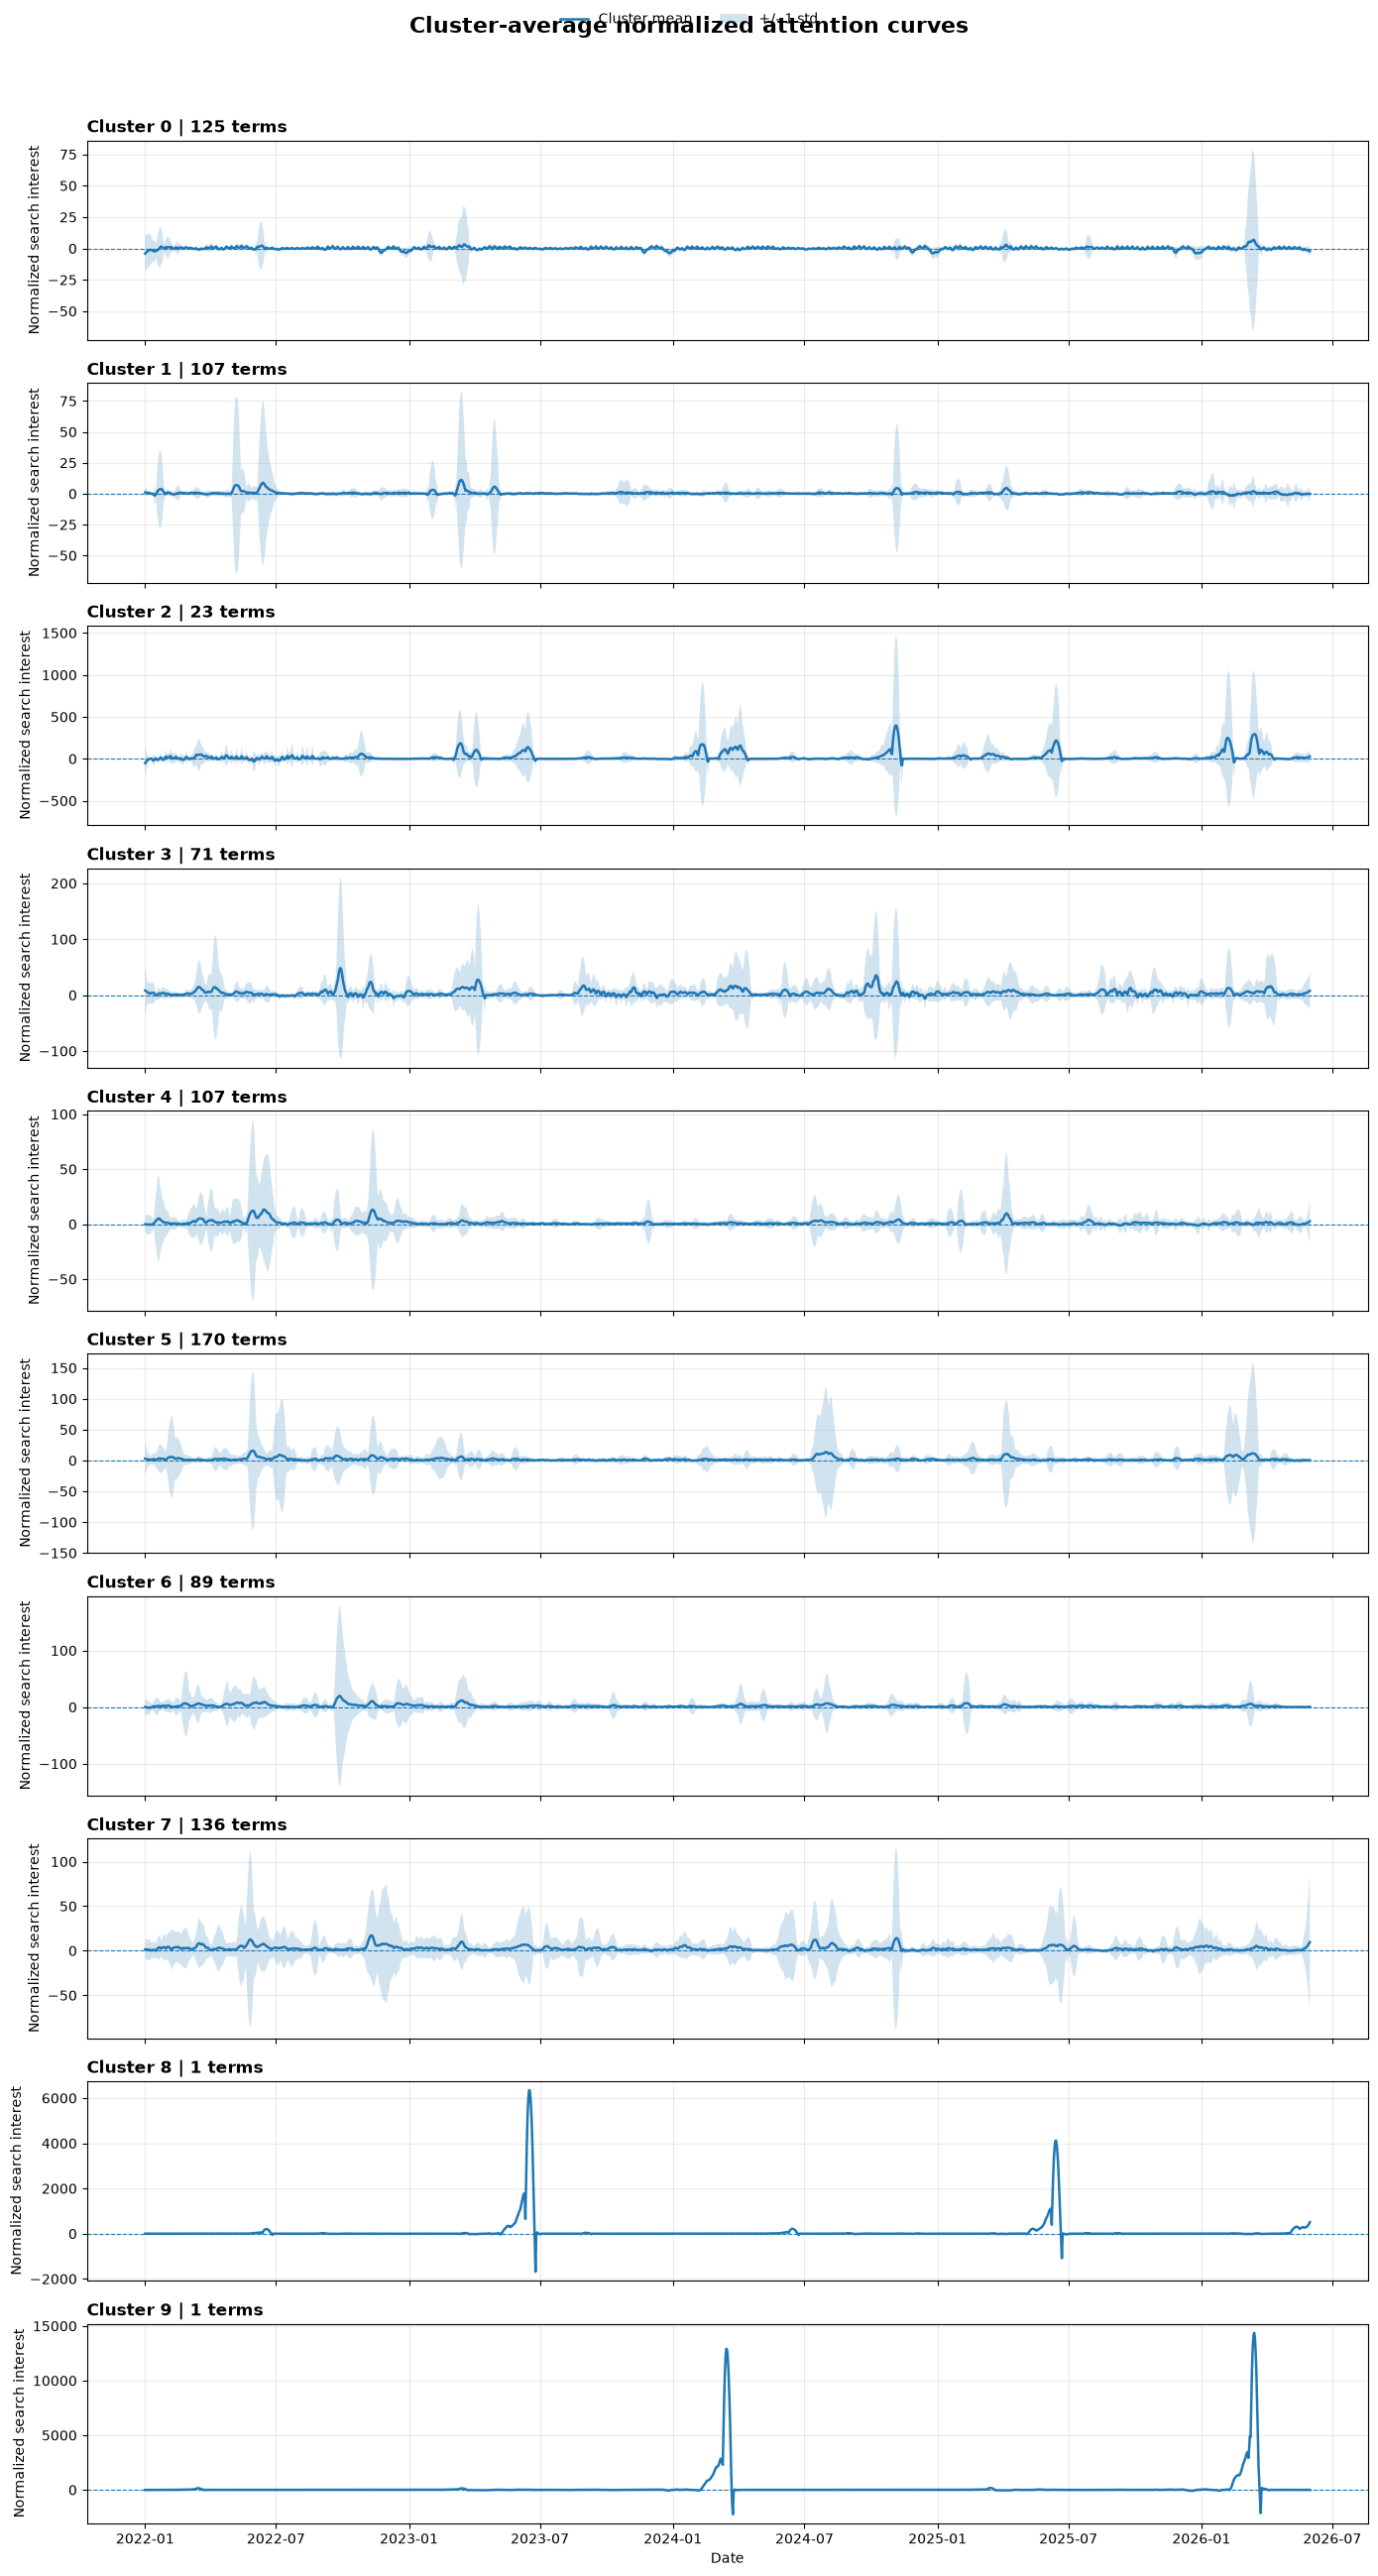

Saved figure to: C:\Python\CSUREMM\output\sax_tests_july_06\12_cluster_mean_std_timeseries.png
Saved summary to: C:\Python\CSUREMM\output\sax_tests_july_06\12_cluster_mean_std_summary.csv


In [3]:
# ----------------------------------------------------------------------------
# Cluster-average time series visualization
# Input:
#   1. consensus labels: 11_consensus_labels.csv
#   2. normalized panel: 02_preprocess_normalized.csv
# Output:
#   cluster summary statistics + cluster mean/std time-series plot
# ----------------------------------------------------------------------------

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ----------------------------------------------------------------------------
# Paths
# ----------------------------------------------------------------------------

OUTPUT_DIR = Path(r"C:\Python\CSUREMM\output\sax_tests_july_06")

LABELS_PATH = OUTPUT_DIR / "11_consensus_labels.csv"
PANEL_NORM_PATH = OUTPUT_DIR / "02_preprocess_normalized.csv"

FIG_PATH = OUTPUT_DIR / "12_cluster_mean_std_timeseries.png"
SUMMARY_PATH = OUTPUT_DIR / "12_cluster_mean_std_summary.csv"


# ----------------------------------------------------------------------------
# Load data
# ----------------------------------------------------------------------------

labels = pd.read_csv(LABELS_PATH)

panel_norm = pd.read_csv(
    PANEL_NORM_PATH,
    index_col=0,
    parse_dates=True
)

panel_norm.index.name = "Time"

labels["term"] = labels["term"].astype(str)
labels["cluster"] = labels["cluster"].astype(int)

# Keep only terms that exist in normalized panel
labels = labels[labels["term"].isin(panel_norm.columns)].copy()

print(f"Terms in labels after matching panel columns: {len(labels)}")


# ----------------------------------------------------------------------------
# 1. Calculate mean and standard deviation for each cluster
# ----------------------------------------------------------------------------

cluster_summary_rows = []
cluster_curves = {}

for cluster_id in sorted(labels["cluster"].unique()):

    terms = (
        labels
        .loc[labels["cluster"] == cluster_id, "term"]
        .tolist()
    )

    cluster_panel = panel_norm[terms]

    cluster_mean = cluster_panel.mean(axis=1, skipna=True)
    cluster_std = cluster_panel.std(axis=1, skipna=True)

    cluster_curves[cluster_id] = {
        "terms": terms,
        "mean": cluster_mean,
        "std": cluster_std,
        "n_terms": len(terms),
    }

    cluster_summary_rows.append({
        "cluster": cluster_id,
        "n_terms": len(terms),
        "avg_level": float(cluster_panel.mean().mean()),
        "avg_volatility": float(cluster_panel.std().mean()),
        "avg_cross_sectional_std": float(cluster_std.mean()),
        "max_cluster_mean": float(cluster_mean.max()),
        "min_cluster_mean": float(cluster_mean.min()),
        "range_cluster_mean": float(cluster_mean.max() - cluster_mean.min()),
    })

cluster_summary = pd.DataFrame(cluster_summary_rows)

cluster_summary.to_csv(
    SUMMARY_PATH,
    index=False
)

print(cluster_summary.to_string(index=False))


# ----------------------------------------------------------------------------
# 2. Plot cluster mean time series with +/- 1 std band
# ----------------------------------------------------------------------------

n_clusters = len(cluster_curves)
n_cols = 1
n_rows = n_clusters

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 2.6 * n_rows),
    sharex=True
)

if n_clusters == 1:
    axes = [axes]

for ax, cluster_id in zip(axes, sorted(cluster_curves.keys())):

    curve = cluster_curves[cluster_id]

    mean = curve["mean"]
    std = curve["std"]

    upper = mean + std
    lower = mean - std

    ax.plot(
        mean.index,
        mean.values,
        linewidth=1.8,
        label="Cluster mean"
    )

    ax.fill_between(
        mean.index,
        lower.values,
        upper.values,
        alpha=0.20,
        label="+/- 1 std"
    )

    ax.axhline(
        0,
        linewidth=0.8,
        linestyle="--"
    )

    ax.set_title(
        f"Cluster {cluster_id} | {curve['n_terms']} terms",
        loc="left",
        fontsize=12,
        fontweight="bold"
    )

    ax.set_ylabel("Normalized search interest")
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel("Date")

handles, labels_legend = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels_legend,
    loc="upper center",
    ncol=2,
    frameon=False
)

fig.suptitle(
    "Cluster-average normalized attention curves",
    fontsize=16,
    fontweight="bold",
    y=0.995
)

plt.tight_layout(rect=[0, 0, 1, 0.975])

plt.savefig(
    FIG_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved figure to: {FIG_PATH}")
print(f"Saved summary to: {SUMMARY_PATH}")

 cluster  n_terms start_date   end_date  window_score  mean_level_short_window  std_level_short_window  max_mean_short_window  min_mean_short_window  range_mean_short_window
       0      125 2025-03-28 2026-03-28      0.389842                 0.304079                1.424124               6.921110              -3.855224                10.776334
       1      107 2021-07-02 2022-07-02      0.297674                 1.410082                2.138962               8.850049              -1.558790                10.408839
       2       23 2021-08-08 2022-08-08      6.784817                 8.483580               17.468889              52.735647             -51.688756               104.424403
       3       71 2022-04-17 2023-04-17      1.251582                 4.579870                7.710161              48.408699              -5.717504                54.126204
       4      107 2021-07-02 2022-07-02      0.436462                 3.225218                3.389261              13.322374     

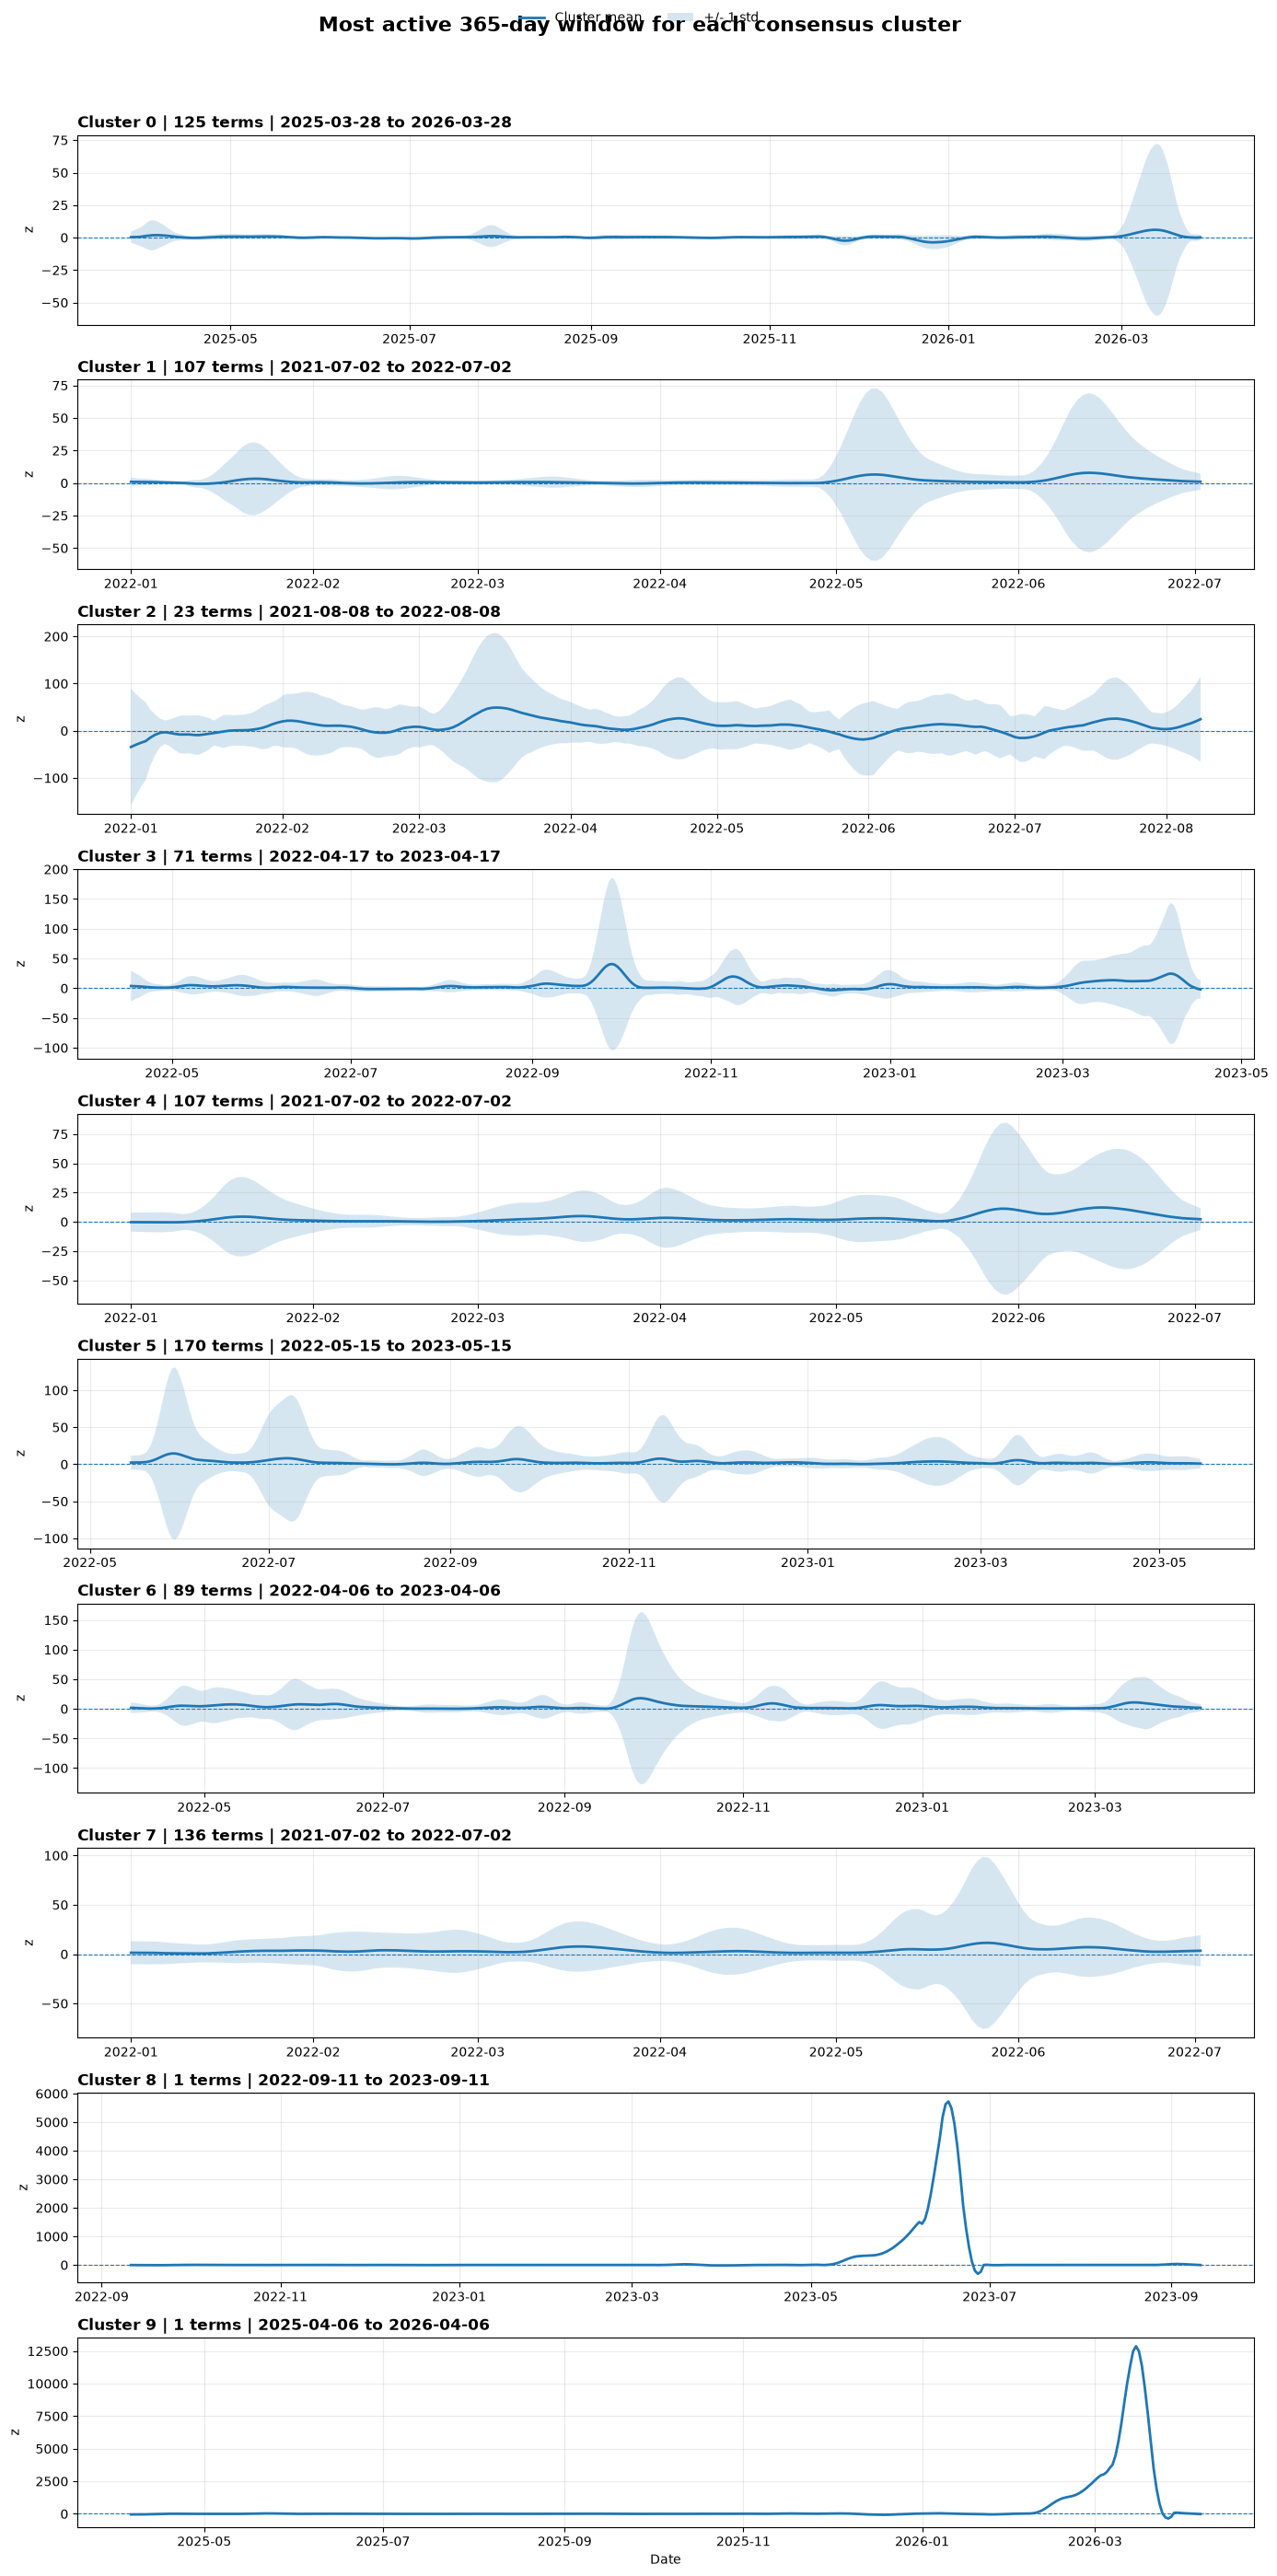

Saved figure to: C:\Python\CSUREMM\output\sax_tests_july_06\13_cluster_short_window_curves.png
Saved summary to: C:\Python\CSUREMM\output\sax_tests_july_06\13_cluster_short_window_summary.csv


In [4]:
# ----------------------------------------------------------------------------
# Short-window cluster curve visualization
# Shows clearer local shapes by plotting the most active 365-day period
# for each cluster, based on cluster mean absolute movement.
# ----------------------------------------------------------------------------

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ----------------------------------------------------------------------------
# Paths
# ----------------------------------------------------------------------------

OUTPUT_DIR = Path(r"C:\Python\CSUREMM\output\sax_tests_july_06")

LABELS_PATH = OUTPUT_DIR / "11_consensus_labels.csv"
PANEL_NORM_PATH = OUTPUT_DIR / "02_preprocess_normalized.csv"

FIG_PATH = OUTPUT_DIR / "13_cluster_short_window_curves.png"
SUMMARY_PATH = OUTPUT_DIR / "13_cluster_short_window_summary.csv"


# ----------------------------------------------------------------------------
# Load data
# ----------------------------------------------------------------------------

labels = pd.read_csv(LABELS_PATH)

panel_norm = pd.read_csv(
    PANEL_NORM_PATH,
    index_col=0,
    parse_dates=True
)

panel_norm.index.name = "Time"

labels["term"] = labels["term"].astype(str)
labels["cluster"] = labels["cluster"].astype(int)

labels = labels[
    labels["term"].isin(panel_norm.columns)
].copy()


# ----------------------------------------------------------------------------
# Helper: find most informative short window per cluster
# ----------------------------------------------------------------------------

SHORT_WINDOW_DAYS = 365
ROLLING_SMOOTH_DAYS = 7

cluster_windows = []
cluster_curves_short = {}

for cluster_id in sorted(labels["cluster"].unique()):

    terms = (
        labels
        .loc[labels["cluster"] == cluster_id, "term"]
        .tolist()
    )

    cluster_panel = panel_norm[terms]

    cluster_mean_full = cluster_panel.mean(axis=1, skipna=True)
    cluster_std_full = cluster_panel.std(axis=1, skipna=True)

    # Score windows by average absolute movement in the cluster mean
    movement = cluster_mean_full.diff().abs()

    window_score = (
        movement
        .rolling(SHORT_WINDOW_DAYS, min_periods=SHORT_WINDOW_DAYS // 2)
        .mean()
    )

    if window_score.dropna().empty:
        end_date = cluster_mean_full.index.max()
    else:
        end_date = window_score.idxmax()

    start_date = end_date - pd.Timedelta(days=SHORT_WINDOW_DAYS)

    mean_short = cluster_mean_full.loc[start_date:end_date]
    std_short = cluster_std_full.loc[start_date:end_date]

    # Light smoothing only for display
    mean_short_smooth = (
        mean_short
        .rolling(ROLLING_SMOOTH_DAYS, min_periods=1, center=True)
        .mean()
    )

    std_short_smooth = (
        std_short
        .rolling(ROLLING_SMOOTH_DAYS, min_periods=1, center=True)
        .mean()
    )

    cluster_curves_short[cluster_id] = {
        "terms": terms,
        "mean": mean_short_smooth,
        "std": std_short_smooth,
        "n_terms": len(terms),
        "start_date": start_date,
        "end_date": end_date,
        "window_score": float(window_score.loc[end_date])
        if end_date in window_score.index and pd.notna(window_score.loc[end_date])
        else np.nan,
    }

    cluster_windows.append({
        "cluster": cluster_id,
        "n_terms": len(terms),
        "start_date": start_date.date(),
        "end_date": end_date.date(),
        "window_score": cluster_curves_short[cluster_id]["window_score"],
        "mean_level_short_window": float(mean_short.mean()),
        "std_level_short_window": float(mean_short.std()),
        "max_mean_short_window": float(mean_short.max()),
        "min_mean_short_window": float(mean_short.min()),
        "range_mean_short_window": float(mean_short.max() - mean_short.min()),
    })


cluster_window_summary = pd.DataFrame(cluster_windows)

cluster_window_summary.to_csv(
    SUMMARY_PATH,
    index=False
)

print(cluster_window_summary.to_string(index=False))


# ----------------------------------------------------------------------------
# Plot: one short-window panel per cluster
# ----------------------------------------------------------------------------

n_clusters = len(cluster_curves_short)

fig, axes = plt.subplots(
    n_clusters,
    1,
    figsize=(14, 2.8 * n_clusters),
    sharex=False
)

if n_clusters == 1:
    axes = [axes]

for ax, cluster_id in zip(axes, sorted(cluster_curves_short.keys())):

    curve = cluster_curves_short[cluster_id]

    mean = curve["mean"]
    std = curve["std"]

    upper = mean + std
    lower = mean - std

    ax.plot(
        mean.index,
        mean.values,
        linewidth=2.0,
        label="Cluster mean"
    )

    ax.fill_between(
        mean.index,
        lower.values,
        upper.values,
        alpha=0.18,
        label="+/- 1 std"
    )

    ax.axhline(
        0,
        linewidth=0.8,
        linestyle="--"
    )

    ax.set_title(
        (
            f"Cluster {cluster_id} | {curve['n_terms']} terms | "
            f"{curve['start_date'].date()} to {curve['end_date'].date()}"
        ),
        loc="left",
        fontsize=12,
        fontweight="bold"
    )

    ax.set_ylabel("z")
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel("Date")

handles, legend_labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    legend_labels,
    loc="upper center",
    ncol=2,
    frameon=False
)

fig.suptitle(
    "Most active 365-day window for each consensus cluster",
    fontsize=16,
    fontweight="bold",
    y=0.995
)

plt.tight_layout(rect=[0, 0, 1, 0.975])

plt.savefig(
    FIG_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved figure to: {FIG_PATH}")
print(f"Saved summary to: {SUMMARY_PATH}")